# Experiment 1: Baseline Reconstruction Quality

This notebook reconstructs the Shepp-Logan phantom using Filtered Back Projection (FBP) with varying numbers of projection angles (360, 180, 90, 45, 20, and 10) to observe baseline visual quality and streak artifacts, as well as computing basic metrics (RMSE, SSIM).

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add the src directory to the path to import custom modules
sys.path.append(os.path.abspath('../src'))

from phantom import generate_shepp_logan
from forward_projection import generate_sinogram
from fbp import reconstruct_fbp
from metrics import compute_rmse, compute_ssim
from utils import display_images_grid, ensure_dir

# Create the results directory if it doesn't exist
ensure_dir('../results')

## 1. Generate Shepp-Logan Phantom

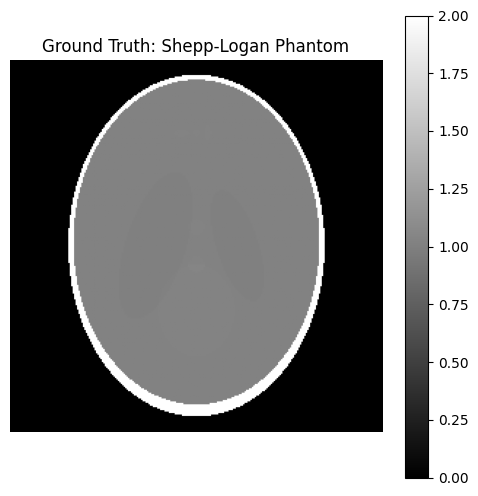

In [ ]:
phantom_size = 256
phantom = generate_shepp_logan(size=phantom_size)

plt.figure(figsize=(6, 6))
plt.imshow(phantom, cmap='gray')
plt.title('Ground Truth: Shepp-Logan Phantom')
plt.axis('off')
plt.colorbar()
plt.show()

## 1.5 Visualize Parallel X-Ray Beams Overlay

Here we overlay the mathematical equations of the parallel rays on top of the phantom to verify the geometry matches the Radon Transform (s, \theta)$.

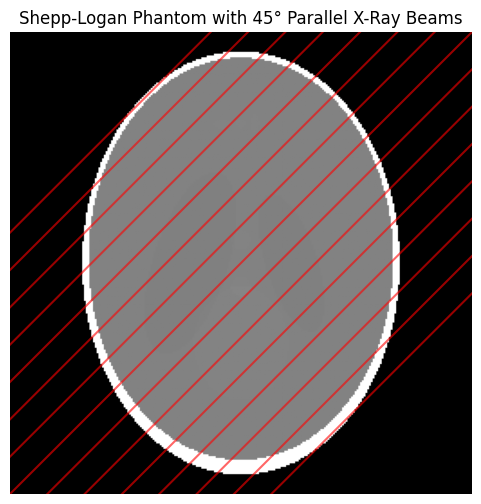

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))
# We set extent to [-1, 1, -1, 1] to match the normalized coordinates used in the forward projector
plt.imshow(phantom, cmap='gray', extent=[-1, 1, 1, -1])

# Draw parallel beams for a specific angle (e.g., 45 degrees)
theta = np.deg2rad(45)
t = np.linspace(-1.5, 1.5, 100) # Ray length slightly longer than the image diagonal

# Plot representative sample rays at different perpendicular offsets (s)
offsets = np.linspace(-0.8, 0.8, 15) 
for s in offsets:
    # Parametric equation of the line integral path:
    # x(t) = s*cos(theta) - t*sin(theta)
    # y(t) = s*sin(theta) + t*cos(theta)
    x = s * np.cos(theta) - t * np.sin(theta)
    y = s * np.sin(theta) + t * np.cos(theta)
    
    plt.plot(x, y, color='red', alpha=0.6, linewidth=1.5)

plt.title('Shepp-Logan Phantom with 45° Parallel X-Ray Beams')
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(1, -1) # y-axis goes down to match image coordinates
plt.show()

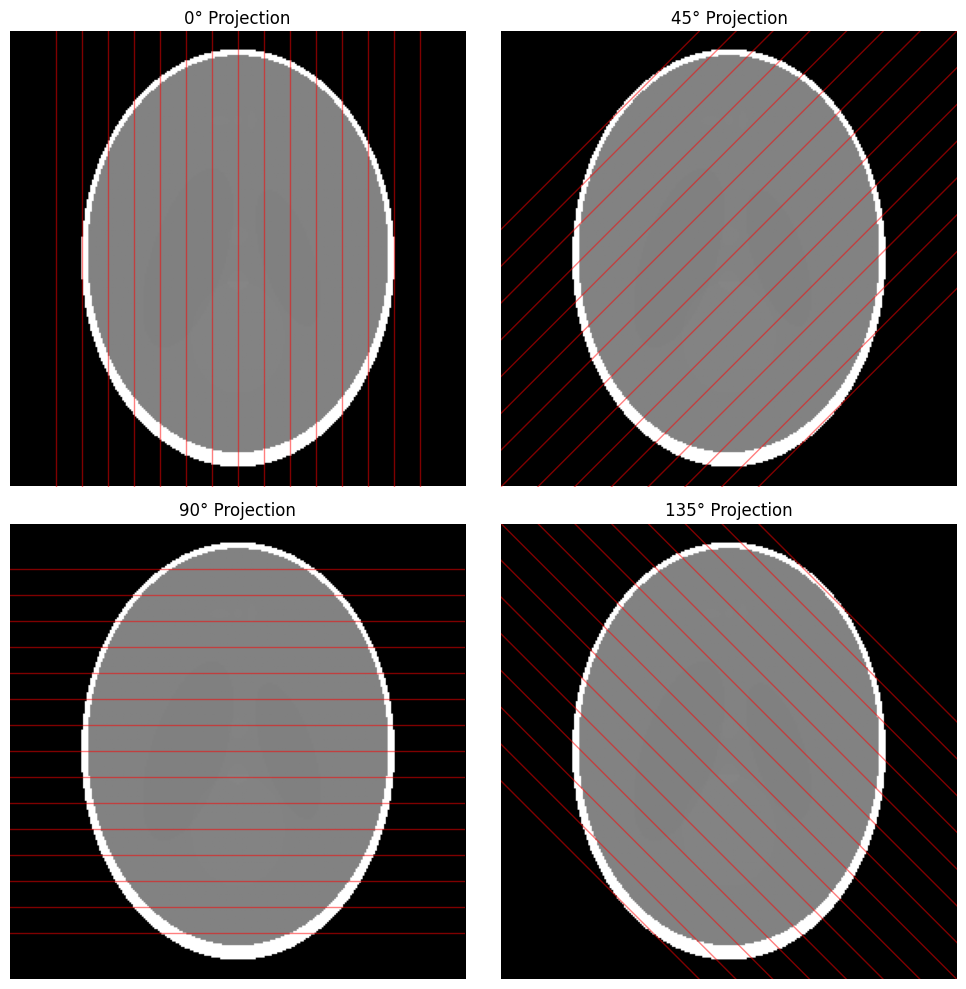

In [13]:
# Let's visualize the beam rotation across multiple angles!
angles_to_plot = [0, 45, 90, 135]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

t = np.linspace(-1.5, 1.5, 100)
offsets = np.linspace(-0.8, 0.8, 15)

for idx, angle_deg in enumerate(angles_to_plot):
    ax = axes[idx]
    ax.imshow(phantom, cmap='gray', extent=[-1, 1, 1, -1])
    
    theta = np.deg2rad(angle_deg)
    for s in offsets:
        x = s * np.cos(theta) - t * np.sin(theta)
        y = s * np.sin(theta) + t * np.cos(theta)
        ax.plot(x, y, color='red', alpha=0.5, linewidth=1)
        
    ax.set_title('{}° Projection'.format(angle_deg))
    ax.axis('off')
    ax.set_xlim(-1, 1)
    ax.set_ylim(1, -1)

plt.tight_layout()
plt.show()

## 2. Reconstruct with Varying Number of Projection Angles

We reconstruct the phantom by simulating a parallel-beam forward projection and then executing the `reconstruct_fbp` function.

In [14]:
angles_list = [360, 180, 90, 45, 20, 10]
reconstructions = []
rmse_values = []
ssim_values = []
titles = []

for num_angles in angles_list:
    print(f"Processing for {num_angles} angles...")
    
    # Generate sinogram
    sinogram, angles_deg = generate_sinogram(phantom, num_angles=num_angles, angle_range=(0, 180))
    
    # Reconstruct using FBP with standard Ram-Lak filter
    reconstruction = reconstruct_fbp(sinogram, angles_deg, filter_name="ram-lak", output_size=phantom_size)
    
    # Calculate basic metrics compared to ground truth
    rmse = compute_rmse(reconstruction, phantom)
    ssim, _ = compute_ssim(reconstruction, phantom)
    
    # Store results
    reconstructions.append(reconstruction)
    rmse_values.append(rmse)
    ssim_values.append(ssim)
    titles.append(f"{num_angles} Angles\nRMSE: {rmse:.4f}, SSIM: {ssim:.4f}")

print("Reconstructions complete.")

Processing for 360 angles...
Processing for 180 angles...
Processing for 90 angles...
Processing for 45 angles...
Processing for 20 angles...
Processing for 10 angles...
Reconstructions complete.


## 3. Visual Comparison of Streak Artifacts

Notice how decreasing the number of projection angles increases the presence of streak artifacts, particularly radiating outward from high contrast boundaries.

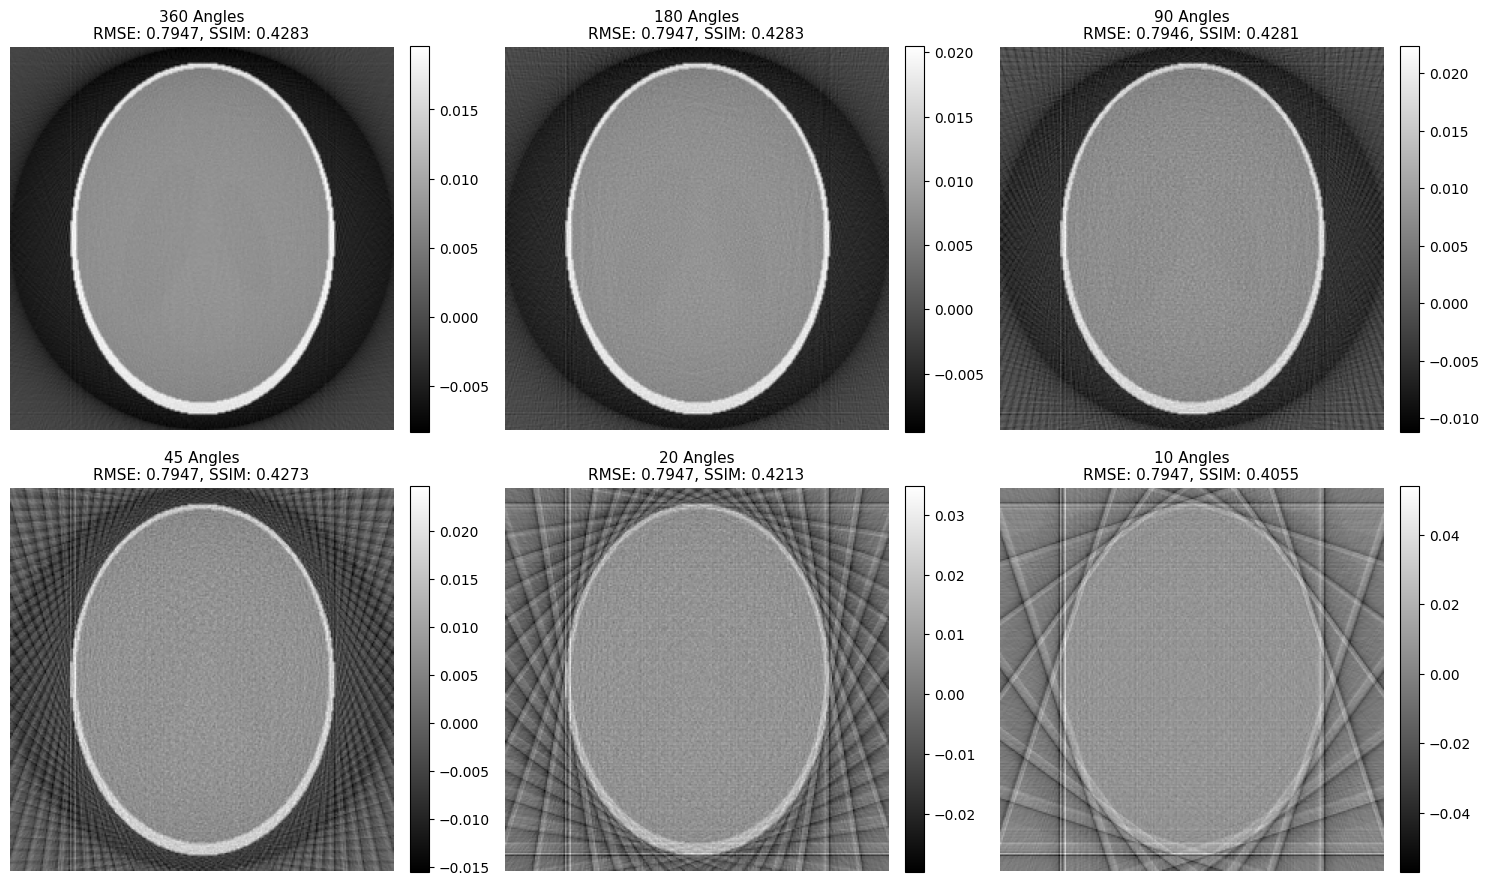

In [7]:
fig = display_images_grid(reconstructions, titles=titles, ncols=3, cmap="gray")

if fig is not None:
    fig.suptitle("Baseline FBP Reconstruction vs. Number of Projection Angles", fontsize=16, y=1.02)
    fig.savefig("../results/experiment_1_visual_comparison.png", bbox_inches='tight')
    plt.show()

## 4. Quantitative Metrics Analysis

Visualizing how image quality correlates with projection counts.

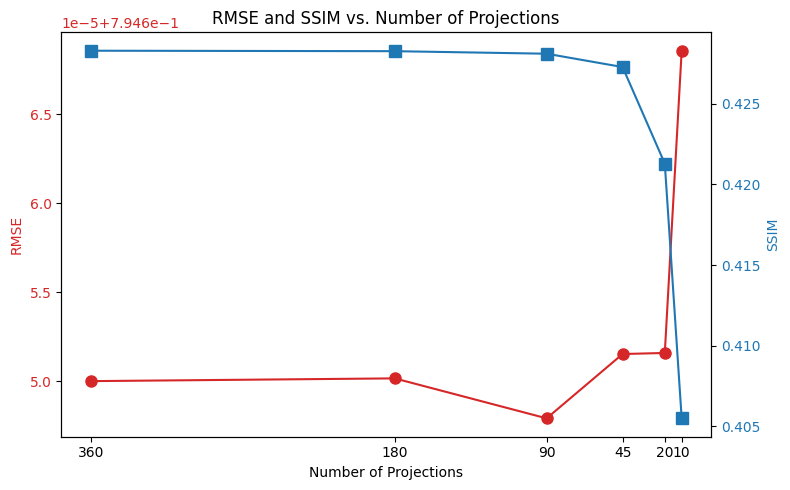

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot RMSE
color = 'tab:red'
ax1.set_xlabel('Number of Projections')
ax1.set_ylabel('RMSE', color=color)
ax1.plot(angles_list, rmse_values, 'o-', color=color, markersize=8, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color)

# Second axes that shares the same x-axis for SSIM
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('SSIM', color=color)  
ax2.plot(angles_list, ssim_values, 's-', color=color, markersize=8, label='SSIM')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('RMSE and SSIM vs. Number of Projections')
ax1.set_xticks(angles_list)
ax1.invert_xaxis()  # Invert x-axis to show degradation as angle counts drop
fig.tight_layout()  
fig.savefig("../results/experiment_1_metrics_plot.png", bbox_inches='tight')
plt.show()